In [75]:
import argparse
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np
import collections
import re
import random
import ast

In [83]:
def reverse_complement(seq: str) -> str:
    complement = str.maketrans('ATCGatcg', 'TAGCtagc')
    return seq.translate(complement)[::-1]


def gRNA_direction(file, analpos):
    # extract the gRNA sequence from the file name
    match = re.search(r'sgRNA_(\w+)\.txt', str(file))
    grna = match.group(1)
    # print(file, grna)
    # Read the file content and search the first Reference_Sequence without gap
    data = pd.read_csv(file, sep='\t')
    ref_seq = ''
    for i in data.index:
        # print(data.at[i, 'Reference_Sequence'])
        if '-' not in data.at[i, 'Reference_Sequence']:
            ref_seq = data.at[i, 'Reference_Sequence']
            break
    if ref_seq=='':
        return '0', '0'
	
    if grna in ref_seq:
        return '+', ref_seq[19 + analpos]
    else:
        return '-', reverse_complement(ref_seq)[19 + analpos]

def insertion_base(product, refseq, gRNA_sign):
    pass
	
def analyse_prodcuts(path, title, th, out, analpos, count, nr):
    if os.path.isfile(path):
        files = [path]
    elif os.path.isdir(path):
        files = list(Path(path).rglob(f"Alleles_frequency_table_around*"))  # Recursively find matching files
    
    insertions_data_dict = {base: {'A': 0, 'C': 0, 'G': 0, 'T': 0} for base in ['A', 'C', 'G', 'T']}   # the dict will contain the observed base at analapos as the first key and the observed base at the insertion as the second key
    insertions_count_dict = {'A': 0.00000001, 'C': 0.00000001, 'G': 0.00000001, 'T': 0.00000001}
    sqa_used = set()
    for f in files:
        # print(f)
        match = re.search(r'(SQA_?#?\d+)', str(f))
        sqa = match.group(1).replace("_", "")
        sqa = match.group(1).replace("#", "")
        if sqa in sqa_used and nr:
            continue
        else:
            sqa_used.add(sqa)
        orientation, pre_cut_base = gRNA_direction(f, analpos)
        if orientation == '0':
            continue
        # print(orientation, pre_cut_base)

        data = pd.read_csv(f, sep='\t')
        for i in data.index:
            ref_seq = data.at[i, 'Reference_Sequence']
            product_seq = data.at[i, 'Aligned_Sequence']
            # print("*", data.at[i, 'n_inserted'])
            if data.at[i, 'n_inserted'] != 1 :
                continue
            # print("**", data.at[i, 'n_inserted'])
            prec = data.at[i, '%Reads']
            if count:
                prec = 1
            if prec < th:
                continue
            insertions_count_dict[pre_cut_base] += prec
            
            insertion_pos = ref_seq.index('-')
            insertion_base = product_seq[insertion_pos]
            # print(data.at[i, 'n_inserted'], orientation, prec, pre_cut_base, insertion_base)
            if insertion_base != 'N':
                if orientation=='+':
                    insertions_data_dict[pre_cut_base][insertion_base] += prec
                elif orientation=='-':
                    insertions_data_dict[pre_cut_base][reverse_complement(insertion_base)] += prec

    # normalize to the number of occerences of the base in analpos position
    # print(insertions_count_dict)

    for i in insertions_data_dict:
        for j in insertions_data_dict[i]:
            insertions_data_dict[i][j] /= insertions_count_dict[i]

    return insertions_data_dict 

def create_plot(insertions_data_dict, title, outfile=None, ax=None):
    data = [list(insertions_data_dict[i].values()) for i in insertions_data_dict]
    ar = np.array(data).T

    cmap = plt.cm.Blues #.reversed()

    if ax is None:
        # No subplot passed → create normal figure
        fig, ax = plt.subplots(figsize=(4,4))
        

    im = ax.imshow(ar, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['A', 'C', 'G', 'T'])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(['A', 'C', 'G', 'T'])
    ax.set_title(title, fontsize=19)
    ax.set_xlabel('base in position -4', fontsize=17)
    ax.set_ylabel('insertion base', fontsize=17)

    # Colorbar only for standalone plots
    if outfile is not None and ax is None:
        plt.colorbar(im)

    if outfile is not None and ax is None:
        plt.savefig(outfile)
        plt.show()

    return im  # return handle so super-plot can add one colorbar

def analyse_multiple_folders(folders, sup_title ,titles, analpos=0, th=0, count=False, nr=True, save_as="combined.svg"):
    n = len(folders)
    rows = int(np.ceil(np.sqrt(n)))
    cols = int(np.ceil(n / rows))

    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    plt.subplots_adjust(
    left=0.08,    # space on the left
    right=0.8,   # leave room on the right for colorbar
    top=0.88,
    bottom=0.08,
    wspace=0.4,   # width space between subplots
    hspace=0.4    # height space between subplots
)
    fig.suptitle(sup_title, fontsize=20, fontweight="bold")
    axs = np.array(axs).reshape(rows, cols)

    last_im = None

    for i, folder in enumerate(folders):
        r, c = divmod(i, cols)
        ax = axs[r, c]
        print(i)
        insertions_data = analyse_prodcuts(
            folder,
            title=titles[i],
            th=th,
            out=None,
            analpos=analpos,
            count=count,
            nr=nr
        )

        last_im = create_plot(insertions_data, titles[i], outfile=None, ax=ax)

    # Remove unused axes
    for j in range(n, rows*cols):
        fig.delaxes(axs.flatten()[j])
    # Place the colorbar in its own axis on the right
    plt.subplots_adjust(right=0.86)     # makes room on the right side
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(last_im, cax=cbar_ax)
    cbar.set_label("Insertion frequency (%)")

    # plt.tight_layout()
    plt.savefig('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/' + save_as)
    plt.show()

In [56]:
def get_short_INS_dicts(folders, sup_title ,titles, analpos=0, th=0, count=False, nr=True, save_as="combined.svg"):
    INS_nts_dicts = {}
    for i, folder in enumerate(folders):
        # print(folder)
        insertions_data = analyse_prodcuts(
            folder,
            title=titles[i],
            th=th,
            out=None,
            analpos=analpos,
            count=count,
            nr=nr
        )
        INS_nts_dicts[folder] = insertions_data
    return INS_nts_dicts

In [57]:
# folder = '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/T'
# title = 'T 1-bp insertion frequency'
# out = "my_plot.svg"
# title = "My Plot Title"
# count = False
# th = 0
# analpos = 0
# nr = True
# analyse_prodcuts(folder, title, th, out, analpos, count, nr)

In [58]:
folders = [
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Human',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato protoplasts',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Prawn',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Fly',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/K562',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/T',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/PLX',
    '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/U937']


titles = [x.split('/')[-1] for x in folders]


sup_title = '1-bp insertion frequncies per organism'
short_INS_dicts = get_short_INS_dicts(
    folders,sup_title,
    titles,
    analpos=0,
    th=0,
    count=False,
    nr=True,
    save_as="organisms_1_bp_insertions.svg"
)

In [59]:
short_INS_dicts.keys()

dict_keys(['/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Human', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato protoplasts', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Prawn', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Fly', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/K562', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/T', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/PLX', '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/U937'])

In [60]:
INS_dicts = {x.split('/')[-1]:short_INS_dicts[x] for x in short_INS_dicts}

In [62]:
INS_dicts['Tomato leaf'] = INS_dicts['Tomato protoplasts'].copy()
del INS_dicts['Tomato protoplasts']

In [67]:
INS_dicts['Tomato hairy roots'] = real

In [70]:
import pickle
with open('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/INS_nts_w_TMH.pkl', 'wb') as file:
    pickle.dump(INS_dicts, file)

0
1
2
3
4
5
6
7
8


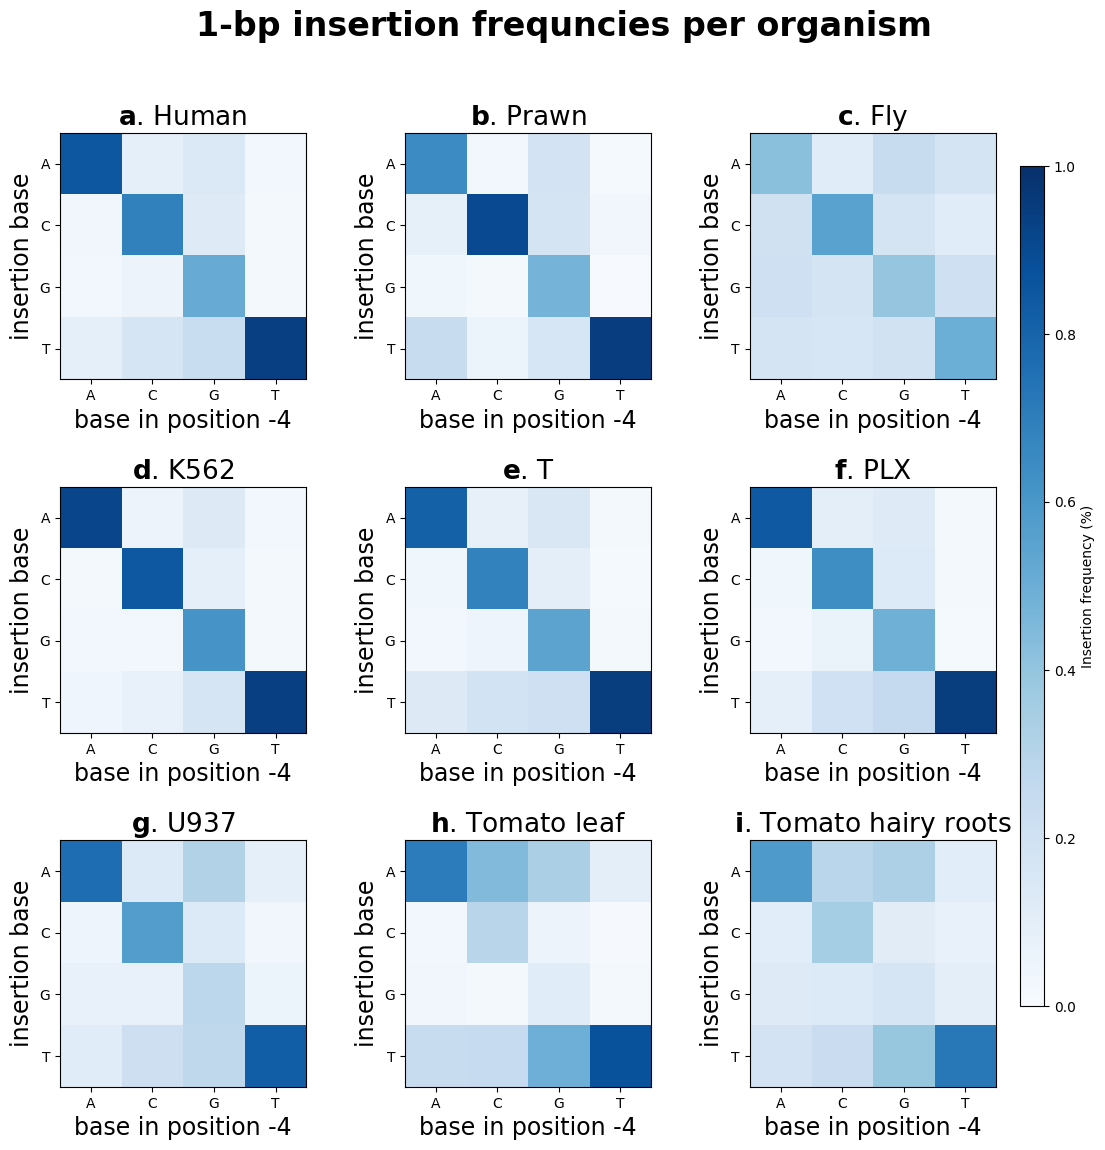

In [84]:
n = len(INS_dicts.keys())
rows = int(np.ceil(np.sqrt(n)))
cols = int(np.ceil(n / rows))
fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
plt.subplots_adjust(
left=0.08,    # space on the left
right=0.8,   # leave room on the right for colorbar
top=0.88,
bottom=0.08,
wspace=0.4,   # width space between subplots
hspace=0.4    # height space between subplots
)
fig.suptitle(sup_title, fontsize=24, fontweight="bold")
axs = np.array(axs).reshape(rows, cols)

last_im = None
ABC = 'abcdefghijk'
for i, k in enumerate(INS_dicts.keys()):
    r, c = divmod(i, cols)
    ax = axs[r, c]
    print(i)
    insertions_data = INS_dicts[k]
    title = rf"$\mathbf{{{ABC[i]}}}$." + ' ' + k
    last_im = create_plot(insertions_data, title, outfile=None, ax=ax)

# Remove unused axes
for j in range(n, rows*cols):
    fig.delaxes(axs.flatten()[j])
# Place the colorbar in its own axis on the right
plt.subplots_adjust(right=0.86)     # makes room on the right side
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label("Insertion frequency (%)")

# plt.tight_layout()
plt.savefig('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/' + 'Fig_8.svg')
plt.show()

In [53]:
def analyse_prodcuts_rand(path, th, analpos, count, nr, rand_i=0):
    # Step 1: collect files
    if os.path.isfile(path):
        files = [path]
    elif os.path.isdir(path):
        files = list(Path(path).rglob(f"Alleles_frequency_table_around*"))

    # Step 2: collect true upstream bases (for later permutation)
    upstream_list = []    # one entry per file
    file_list_ordered = []  # preserve ordering for mapping

    for f in files:
        orientation, pre_cut_base = gRNA_direction(f, analpos)
        if orientation != '0':   # valid orientation
            upstream_list.append(pre_cut_base)
            file_list_ordered.append(f)

    # Step 3: PERMUTE if rand_i != 0
    permuted_upstream = {}
    if rand_i != 0:
        import random
        random.seed(rand_i)
        shuffled = upstream_list.copy()
        random.shuffle(shuffled)

        # map file → permuted upstream base
        permuted_upstream = {
            file_list_ordered[i]: shuffled[i]
            for i in range(len(file_list_ordered))
        }

    # -----------------------------------------
    # Continue with your regular analysis
    # -----------------------------------------

    insertions_data_dict = {base: {'A': 0, 'C': 0, 'G': 0, 'T': 0} 
                             for base in ['A','C','G','T']}
    insertions_count_dict = {'A': 1e-8, 'C': 1e-8, 'G': 1e-8, 'T': 1e-8}

    sqa_used = set()
    for f in files:
        match = re.search(r'(SQA_?#?\d+)', str(f))
        sqa = match.group(1).replace("_", "").replace("#", "")

        if sqa in sqa_used and nr:
            continue
        sqa_used.add(sqa)

        orientation, pre_cut_base = gRNA_direction(f, analpos)
        if orientation == '0':
            continue

        # ★ Apply permutation if needed
        if rand_i != 0:
            pre_cut_base = permuted_upstream[f]

        data = pd.read_csv(f, sep='\t')
        for i in data.index:
            if data.at[i, 'n_inserted'] != 1:
                continue

            prec = 1 if count else data.at[i, '%Reads']
            if prec < th:
                continue

            insertions_count_dict[pre_cut_base] += prec

            ref_seq = data.at[i, 'Reference_Sequence']
            product_seq = data.at[i, 'Aligned_Sequence']
            insertion_pos = ref_seq.index('-')
            insertion_base = product_seq[insertion_pos]

            if insertion_base != 'N':
                if orientation == '+':
                    insertions_data_dict[pre_cut_base][insertion_base] += prec
                else:
                    ins = reverse_complement(insertion_base)
                    insertions_data_dict[pre_cut_base][ins] += prec

    # Normalize
    for u in insertions_data_dict:
        for b in insertions_data_dict[u]:
            insertions_data_dict[u][b] /= insertions_count_dict[u]

    return insertions_data_dict


In [63]:
source_fold = '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/PLX'
analyse_prodcuts_rand(source_fold, th, analpos, count, nr, rand_i=0)

{'A': {'A': np.float64(0.842435740211346),
  'C': np.float64(0.03675554322151576),
  'G': np.float64(0.02888880633018643),
  'T': np.float64(0.09191991023084234)},
 'C': {'A': np.float64(0.09415677671481787),
  'C': np.float64(0.6385593181287633),
  'G': np.float64(0.06591211917641562),
  'T': np.float64(0.2013717859718835)},
 'G': {'A': np.float64(0.12236792857883176),
  'C': np.float64(0.13630824478305356),
  'G': np.float64(0.4889937027991459),
  'T': np.float64(0.25233012382442616)},
 'T': {'A': np.float64(0.021441898348715852),
  'C': np.float64(0.016294204351292987),
  'G': np.float64(0.013255486323900044),
  'T': np.float64(0.949008410967478)}}

In [75]:
def analyse_df_window_random(
        df,
        num_random=0,
        random_seed=0,
        window_size=5,
        weight_by_reads=True):
    """
    df columns needed:
      amp
      origin
      pos_INS_nts   <-- string of dict {"A":count,...}
      gRNA          <-- 20nt sequence
      strand_gRNA_in_amp  ('+' or '-')
    
    Output:
      real_matrix, list_of_random_matrices
    """

    events = []

    for idx, row in df.iterrows():

        # ---------------------------------------------
        # 1. Parse insertion dictionary
        # ---------------------------------------------
        ins_dict = ast.literal_eval(row["pos_INS_nts"])
        # ensure keys always uppercase
        ins_dict = {k.upper(): ins_dict[k] for k in ins_dict}

        # reverse complement dictionary if gRNA negative orientation
        strand = row["strand_gRNA_in_amp"]
        if strand == "-":
            ins_dict = revcomp_dict(ins_dict)

        # ---------------------------------------------
        # 2. Determine gRNA seq and cut site
        # ---------------------------------------------
        gRNA = row["gRNA"].upper()

        if strand == "+":
            grna_seq = gRNA
        else:
            grna_seq = revcomp_seq(gRNA)

        # Cas9 canonical cut is 3 bp upstream of PAM
        # gRNA is 20 nt → cut is between positions 17|18 (0-based index 17)
        cut_index = 17  

        # upstream base:
        real_upstream = grna_seq[cut_index - 1]   # 1 nt upstream of cut

        # ---------------------------------------------
        # 3. Build window around cut site (±window_size)
        # ---------------------------------------------
        window = []
        for o in range(-window_size, window_size + 1):
            if o == 0:
                continue
            pos = cut_index + o
            if 0 <= pos < len(grna_seq):
                window.append(grna_seq[pos])

        # ---------------------------------------------
        # 4. Create events: one event per inserted base category
        # ins_dict gives counts for A/C/G/T
        # ---------------------------------------------
        for base, count in ins_dict.items():
            if count == 0:
                continue

            weight = count if weight_by_reads else 1

            events.append({
                "real_upstream": real_upstream,
                "inserted_base": base,
                "weight": weight,
                "window": window
            })

    # ======================================================
    # Helper: compute normalized 4×4 upstream→insertion matrix
    # ======================================================
    def compute_matrix(upstreams):
        mat = {u: {b: 0 for b in "ACGT"} for u in "ACGT"}
        counts = {u: 1e-8 for u in "ACGT"}

        for e, u in zip(events, upstreams):
            ins_base = e["inserted_base"]
            w = e["weight"]
            counts[u] += w
            mat[u][ins_base] += w

        for u in mat:
            for b in mat[u]:
                mat[u][b] /= counts[u]

        return mat

    # ======================================================
    # REAL RESULTS
    # ======================================================
    real_upstreams = [e["real_upstream"] for e in events]
    real_matrix = compute_matrix(real_upstreams)

    # ======================================================
    # RANDOMIZED RESULTS
    # ======================================================
    null_results = []
    random.seed(random_seed)

    for _ in range(num_random):
        random_upstreams = [
            random.choice(e["window"])
            for e in events
        ]
        null_results.append(compute_matrix(random_upstreams))

    return real_matrix, null_results


In [100]:
num_to_randomize = 1000
main_folder = '/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/'
for x in ['Human', 'K562', 'T', 'U937','PLX', 'Fly','Prawn', 'Tomato protoplasts' ]:
    print(x)
    real, nulls = analyse_prodcuts_window_random(
        main_folder+x, title, th, out, analpos, count, nr,
        num_random=num_to_randomize)
    print('num rands', num_to_randomize)
    AA=0
    CC=0
    GG=0
    TT=0
    for i in range(len(nulls)):
        if nulls[i]['A']['A']>real['A']['A']:
            AA+=1
        if nulls[i]['C']['C']>real['C']['C']:
            CC+=1
        if nulls[i]['G']['G']>real['G']['G']:
            GG+=1
        if nulls[i]['T']['T']>real['T']['T']:
            TT+=1
    print('AA', AA,'CC', CC, 'GG', GG, 'TT', TT)
    print('-----------------------')

Human
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
K562
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
T
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
U937
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
PLX
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
Fly
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
Prawn
num rands 1000
AA 0 CC 0 GG 0 TT 0
-----------------------
Tomato protoplasts
num rands 1000
AA 0 CC 0 GG 31 TT 0
-----------------------


In [13]:
tmh_df.INS_nts.iloc[0]

"{'A': 0.0001252975817566721, 'C': 0.0, 'G': 0.0, 'T': 0.0}"

In [5]:
tmh_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/thr_no_subs_no_splits_11_12_25.csv') 


In [14]:
# tmh_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/SG_DG_thr_no_subs_no_splits_1_12_25.csv') 
tmh_df['pos_INS_nts'] = tmh_df['INS_nts'].copy()
tmh_df = tmh_df.drop(columns=['INS_nts'])

In [112]:
tmh_df.to_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato hairy roots results/SG_DG_thr_no_subs_no_splits_1_12_25.csv', index=False)

In [7]:
def revcomp_base(x):
    return {'A':'T','T':'A','G':'C','C':'G'}[x]

def revcomp_dict(d):
    """Reverse complement dictionary with A/C/G/T keys."""
    return { revcomp_base(k): v for k, v in d.items() }

def revcomp_seq(s):
    return ''.join(revcomp_base(b) for b in reversed(s))

In [17]:
def find_grna_position(grna, amp):
    """Return (position, strand) if found, else (None, None)."""
    if grna in amp:
        return amp.index(grna), "+"
    rc = reverse_complement(grna)
    if rc in amp:
        return amp.index(rc), "-"
    return None, None

In [19]:
tmh_2_df = pd.read_csv('/tamir2/shaicohen1/CRISPR_MAAGAD/For_Eran/Tomato-hairy-roots_eff (2).csv')

In [25]:
tmh_2_df.columns

Index(['Unnamed: 0', 'SiteName', 'AmpliconReference', 'gRNA', 'OnTarget',
       'ForwardPrimer', 'R_PRIMER', 'cell_type', 'sqa', 'new_loc',
       ...
       'sites_count_genome_-20_d0', 'sites_count_genome_-20_d1',
       'sites_count_genome_-20_d2', 'sites_count_genome_-20_d3',
       'sites_count_genome_-20_d4', 'sites_count_genome_-20_d5',
       'CRISPRedict_eff', 'DeepCRISPR_eff', 'uCRISPR_eff', 'SPROUT_eff'],
      dtype='object', length=567)

In [31]:
for i in tmh_df.index:
    name = tmh_df.loc[i,'amp']
    amp_ref = tmh_2_df[tmh_2_df['SiteName']==name].AmpliconReference.iloc[0]
    gRNA = tmh_2_df[tmh_2_df['SiteName']==name].gRNA.iloc[0]
    tmh_df.loc[i,'gRNA'] = gRNA
    if gRNA in amp_ref:
        tmh_df.loc[i,'strand_gRNA_in_amp'] = '+'
    else:
        tmh_df.loc[i,'strand_gRNA_in_amp'] = '-'

In [32]:
def TMH_analyse_df_window_random(
        df,
        num_random=0,
        window_size=5,
        weight_by_reads=True):
    """
    df columns needed:
      amp
      origin
      pos_INS_nts   <-- string of dict {"A":count,...}
      gRNA          <-- 20nt sequence
      strand_gRNA_in_amp  ('+' or '-')
    
    Output:
      real_matrix, list_of_random_matrices
    """

    events = []

    for idx, row in df.iterrows():

        # ---------------------------------------------
        # 1. Parse insertion dictionary
        # ---------------------------------------------
        ins_dict = ast.literal_eval(row["pos_INS_nts"])
        # ensure keys always uppercase
        ins_dict = {k.upper(): ins_dict[k] for k in ins_dict}

        # reverse complement dictionary if gRNA negative orientation
        strand = row["strand_gRNA_in_amp"]
        if strand == "-":
            ins_dict = revcomp_dict(ins_dict)

        # ---------------------------------------------
        # 2. Determine gRNA seq and cut site
        # ---------------------------------------------
        grna_seq = row["gRNA"].upper()

        # if strand == "+":
        #     grna_seq = gRNA
        # else:
        #     grna_seq = revcomp_seq(gRNA)

        # Cas9 canonical cut is 3 bp upstream of PAM
        # gRNA is 20 nt → cut is between positions 17|18 (0-based index 17)
        cut_index = 17  

        # upstream base:
        real_upstream = grna_seq[cut_index - 1]   # 1 nt upstream of cut

        # ---------------------------------------------
        # 3. Build window around cut site (±window_size)
        # ---------------------------------------------
        window = []
        for o in range(-window_size, window_size + 1):
            if o == 0:
                continue
            pos = cut_index + o
            if 0 <= pos < len(grna_seq):
                window.append(grna_seq[pos])

        # ---------------------------------------------
        # 4. Create events: one event per inserted base category
        # ins_dict gives counts for A/C/G/T
        # ---------------------------------------------
        for base, count in ins_dict.items():
            if count == 0:
                continue

            weight = count if weight_by_reads else 1

            events.append({
                "real_upstream": real_upstream,
                "inserted_base": base,
                "weight": weight,
                "window": window
            })

    # ======================================================
    # Helper: compute normalized 4×4 upstream→insertion matrix
    # ======================================================
    def compute_matrix(upstreams):
        mat = {u: {b: 0 for b in "ACGT"} for u in "ACGT"}
        counts = {u: 1e-8 for u in "ACGT"}

        for e, u in zip(events, upstreams):
            ins_base = e["inserted_base"]
            w = e["weight"]
            counts[u] += w
            mat[u][ins_base] += w

        for u in mat:
            for b in mat[u]:
                mat[u][b] /= counts[u]

        return mat

    # ======================================================
    # REAL RESULTS
    # ======================================================
    real_upstreams = [e["real_upstream"] for e in events]
    real_matrix = compute_matrix(real_upstreams)

    # ======================================================
    # RANDOMIZED RESULTS
    # ======================================================
    null_results = []

    for random_seed in range(num_random):
        random.seed(random_seed)
        random_upstreams = [
            random.choice(e["window"])
            for e in events
        ]
        null_results.append(compute_matrix(random_upstreams))

    return real_matrix, null_results


In [33]:
real, nulls = TMH_analyse_df_window_random(
    df=tmh_df,
    num_random=1000,
    weight_by_reads=True
)

In [114]:
real

{'A': {'A': 0.6019893566630626,
  'C': 0.10412081023094813,
  'G': 0.11688166949928482,
  'T': 0.17700816360642585},
 'C': {'A': 0.30077167498837876,
  'C': 0.33781207444363337,
  'G': 0.13463458919642793,
  'T': 0.22678166137065203},
 'G': {'A': 0.3317669674799318,
  'C': 0.11357932397067678,
  'G': 0.18048806536007878,
  'T': 0.37416564318877865},
 'T': {'A': 0.11627591814603773,
  'C': 0.07263856891174385,
  'G': 0.09626417310380979,
  'T': 0.7148213398379568}}

In [34]:
AA=0
CC=0
GG=0
TT=0
for i in range(len(nulls)):
    if nulls[i]['A']['A']>real['A']['A']:
        AA+=1
    if nulls[i]['C']['C']>real['C']['C']:
        CC+=1
    if nulls[i]['G']['G']>real['G']['G']:
        GG+=1
    if nulls[i]['T']['T']>real['T']['T']:
        TT+=1
print('AA', AA,'CC', CC, 'GG', GG, 'TT', TT)

AA 0 CC 0 GG 30 TT 0


In [119]:
nulls[4]['G']['G']

0.16561423650967966

In [121]:
len(nulls)

1000

In [40]:
p_values=[0.001]*((4*9)-2)
p_values.append(0.03)
p_values.append(0.031)

In [41]:
import statsmodels.stats.multitest as smm


In [42]:
reject, pvals_corrected, _, _ = smm.multipletests(
        p_values, 
        alpha=0.05,  # The desired FDR level (e.g., 0.05)
        method='fdr_bh'
    )

In [43]:
pvals_corrected

array([0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.00105882,
       0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.00105882,
       0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.00105882,
       0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.00105882,
       0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.00105882,
       0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.00105882,
       0.00105882, 0.00105882, 0.00105882, 0.00105882, 0.03085714,
       0.031     ])